<a href="https://colab.research.google.com/github/Drinkler/Yield-Prediction/blob/main/Yield_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# General

In [1]:
# Imports
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load cleaned local datasets (no URLs anymore)
pesticides_url   = "res/pesticides_clean.csv"
rainfall_url     = "res/rainfall_yearly.csv"
temperature_url  = "res/temperature_yearly.csv"
yield_url      = "res/yield_final.csv"

print("Using cleaned datasets from local res/ folder")


Using cleaned datasets from local res/ folder


In [3]:
# Load cleaned datasets (normal CSV)
pesticides_data = pd.read_csv(pesticides_url)
rainfall_data = pd.read_csv(rainfall_url)
temperature_data = pd.read_csv(temperature_url)
yield_data = pd.read_csv(yield_url)

print("All cleaned datasets loaded")

All cleaned datasets loaded


#Data Preparation


## Rainfall data

In [4]:
rainfall_data

,Country,Year,Rainfall
0,Afghanistan,1901,20.910303
1,Afghanistan,1902,18.274763
2,Afghanistan,1903,26.209917
3,Afghanistan,1904,24.898845
4,Afghanistan,1905,22.511498
...,...,...,...
22731,Zimbabwe,2012,45.312368
22732,Zimbabwe,2013,51.234424
22733,Zimbabwe,2014,50.608135
22734,Zimbabwe,2015,32.552881


In [5]:
rainfall_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22736 entries, 0 to 22735
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Country   22736 non-null  object 
 1   Year      22736 non-null  int64  
 2   Rainfall  22736 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 533.0+ KB


In [6]:
rainfall_data.describe()

,Year,Rainfall
count,22736.000000,22736.000000
mean,1958.500000,103.470868
std,33.485808,79.734835
min,1901.000000,0.291037
25%,1929.750000,45.409890
50%,1958.500000,86.110804
75%,1987.250000,145.222906
max,2016.000000,782.373333


In [7]:
# Number of countries
len(rainfall_data['Country'].unique())

196

In [8]:
# Number of years (1901 - 2016)
len(rainfall_data['Year'].unique())

116

In [9]:
# One year from Afghanistan
rainfall_data.head(12)

,Country,Year,Rainfall
0,Afghanistan,1901,20.910303
1,Afghanistan,1902,18.274763
2,Afghanistan,1903,26.209917
3,Afghanistan,1904,24.898845
4,Afghanistan,1905,22.511498
5,Afghanistan,1906,24.306363
6,Afghanistan,1907,23.882715
7,Afghanistan,1908,27.671773
8,Afghanistan,1909,25.171232
9,Afghanistan,1910,24.378196


In [10]:
# Rain data is already yearly and cleaned
rainfall_df = rainfall_data[['Country', 'Year', 'Rainfall']]
rainfall_df

,Country,Year,Rainfall
0,Afghanistan,1901,20.910303
1,Afghanistan,1902,18.274763
2,Afghanistan,1903,26.209917
3,Afghanistan,1904,24.898845
4,Afghanistan,1905,22.511498
...,...,...,...
22731,Zimbabwe,2012,45.312368
22732,Zimbabwe,2013,51.234424
22733,Zimbabwe,2014,50.608135
22734,Zimbabwe,2015,32.552881


## Temperature data

In [11]:
temperature_data

,Country,Year,Temperature
0,Afghanistan,1901,13.172872
1,Afghanistan,1902,13.342649
2,Afghanistan,1903,12.006417
3,Afghanistan,1904,12.531729
4,Afghanistan,1905,12.267143
...,...,...,...
22731,Zimbabwe,2012,21.910075
22732,Zimbabwe,2013,21.624350
22733,Zimbabwe,2014,21.710483
22734,Zimbabwe,2015,22.327625


In [12]:
temperature_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22736 entries, 0 to 22735
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      22736 non-null  object 
 1   Year         22736 non-null  int64  
 2   Temperature  22736 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 533.0+ KB


In [13]:
temperature_data.describe()

,Year,Temperature
count,22736.000000,22736.000000
mean,1958.500000,18.631498
std,33.485808,8.741076
min,1901.000000,-20.379517
25%,1929.750000,10.765604
50%,1958.500000,22.555112
75%,1987.250000,25.481144
max,2016.000000,29.695133


In [14]:
# Number of countries
len(temperature_data['Country'].unique())

196

In [15]:
# Number of years (1901 - 2016)
len(temperature_data['Year'].unique())

116

In [16]:
# One year from Afghanistan
temperature_data.head(12)

,Country,Year,Temperature
0,Afghanistan,1901,13.172872
1,Afghanistan,1902,13.342649
2,Afghanistan,1903,12.006417
3,Afghanistan,1904,12.531729
4,Afghanistan,1905,12.267143
5,Afghanistan,1906,12.827208
6,Afghanistan,1907,12.129302
7,Afghanistan,1908,12.517842
8,Afghanistan,1909,13.040823
9,Afghanistan,1910,12.369605


In [17]:
# Average temperature data in years for each country
temperature_df = temperature_data[['Country', 'Year', 'Temperature']]
temperature_df

,Country,Year,Temperature
0,Afghanistan,1901,13.172872
1,Afghanistan,1902,13.342649
2,Afghanistan,1903,12.006417
3,Afghanistan,1904,12.531729
4,Afghanistan,1905,12.267143
...,...,...,...
22731,Zimbabwe,2012,21.910075
22732,Zimbabwe,2013,21.624350
22733,Zimbabwe,2014,21.710483
22734,Zimbabwe,2015,22.327625



## Yield data

In [18]:
yield_data

,Country,Year,Item,Yield (hg/ha)
0,Afghanistan,1961,Barley,10800
1,Afghanistan,1962,Barley,10800
2,Afghanistan,1963,Barley,10800
3,Afghanistan,1964,Barley,10857
4,Afghanistan,1965,Barley,10857
...,...,...,...,...
63686,Zimbabwe,2015,Wheat,20486
63687,Zimbabwe,2016,Wheat,19013
63688,Zimbabwe,2017,Wheat,17542
63689,Zimbabwe,2018,Wheat,16379


In [19]:
yield_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63691 entries, 0 to 63690
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country        63691 non-null  object
 1   Year           63691 non-null  int64 
 2   Item           63691 non-null  object
 3   Yield (hg/ha)  63691 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.9+ MB


In [20]:
yield_data.describe()

,Year,Yield (hg/ha)
count,63691.000000,6.369100e+04
mean,1992.332669,8.581113e+04
std,16.888797,1.008880e+05
min,1961.000000,0.000000e+00
25%,1978.000000,1.770700e+04
50%,1994.000000,4.705900e+04
75%,2007.000000,1.185070e+05
max,2019.000000,2.236842e+06


In [21]:
# Number of countries
len(yield_data['Country'].unique())

203

In [22]:
# Number of years (1961 - 2019)
len(yield_data['Year'].unique())

59

In [23]:
# Remove unnecessary columns
yield_df = yield_data[['Country', 'Year', 'Yield (hg/ha)']]
yield_df

,Country,Year,Yield (hg/ha)
0,Afghanistan,1961,10800
1,Afghanistan,1962,10800
2,Afghanistan,1963,10800
3,Afghanistan,1964,10857
4,Afghanistan,1965,10857
...,...,...,...
63686,Zimbabwe,2015,20486
63687,Zimbabwe,2016,19013
63688,Zimbabwe,2017,17542
63689,Zimbabwe,2018,16379


## Pesticides data

In [24]:
pesticides_data

,Country,Year,Pesticides
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0
...,...,...,...
4784,Zimbabwe,2014,2185.0
4785,Zimbabwe,2015,2185.0
4786,Zimbabwe,2016,2185.0
4787,Zimbabwe,2017,2185.0


In [25]:
pesticides_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4789 entries, 0 to 4788
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     4789 non-null   object 
 1   Year        4789 non-null   int64  
 2   Pesticides  4789 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 112.4+ KB


In [26]:
pesticides_data.describe()

,Year,Pesticides
count,4789.000000,4.789000e+03
mean,2004.142619,2.894718e+04
std,8.302595,1.627207e+05
min,1990.000000,0.000000e+00
25%,1997.000000,9.900000e+01
50%,2004.000000,1.221000e+03
75%,2011.000000,7.420000e+03
max,2018.000000,1.815690e+06


In [27]:
# Number of countries
len(pesticides_data['Country'].unique())

172

In [28]:
# Number of years (1990 - 2018)
len(pesticides_data['Year'].unique())

29

In [29]:
# Remove unnecessary columns
pesticides_df = pesticides_data[['Country', 'Year', 'Pesticides']]
pesticides_df

,Country,Year,Pesticides
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0
...,...,...,...
4784,Zimbabwe,2014,2185.0
4785,Zimbabwe,2015,2185.0
4786,Zimbabwe,2016,2185.0
4787,Zimbabwe,2017,2185.0


## Merging

In [30]:
rainfall_df.rename({'Rainfall': 'Rainfall (mm)'}, axis=1, inplace=True)

In [31]:
temperature_df.rename({'Temperature': 'Temperature (Celsius)'}, axis=1, inplace=True)

In [32]:
yield_df.rename({'Yield (hg/ha)': 'Yield (hg/ha)'}, axis=1, inplace=True)  # already correct
# No 'Unit' column exists in cleaned data, so nothing to drop
yield_df

/var/folders/3j/8s97_xgd4735v6_5l0z3tps40000gn/T/ipykernel_52345/2892578623.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yield_df.rename({'Yield (hg/ha)': 'Yield (hg/ha)'}, axis=1, inplace=True)  # already correct


,Country,Year,Yield (hg/ha)
0,Afghanistan,1961,10800
1,Afghanistan,1962,10800
2,Afghanistan,1963,10800
3,Afghanistan,1964,10857
4,Afghanistan,1965,10857
...,...,...,...
63686,Zimbabwe,2015,20486
63687,Zimbabwe,2016,19013
63688,Zimbabwe,2017,17542
63689,Zimbabwe,2018,16379


In [33]:
pesticides_df.rename({'Pesticides': 'Pesticides (tonnes)'}, axis=1, inplace=True)
# No 'Unit' or 'Item' columns exist in cleaned data
pesticides_df

,Country,Year,Pesticides (tonnes)
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0
...,...,...,...
4784,Zimbabwe,2014,2185.0
4785,Zimbabwe,2015,2185.0
4786,Zimbabwe,2016,2185.0
4787,Zimbabwe,2017,2185.0


In [34]:
rain_temp_df = pd.merge(rainfall_df, temperature_df, on=['Country', 'Year'])

rain_temp_yield_df = pd.merge(
    rain_temp_df,
    yield_data[['Country', 'Year', 'Item', 'Yield (hg/ha)']],
    on=['Country', 'Year']
)

rain_temp_yield_pest_df = pd.merge(
    rain_temp_yield_df,
    pesticides_df,
    on=['Country', 'Year']
)

data = rain_temp_yield_pest_df
data

,Country,Year,Rainfall (mm),Temperature (Celsius),Item,Yield (hg/ha),Pesticides (tonnes)
0,Albania,1990,67.686208,12.051221,Barley,10000,121.0
1,Albania,1990,67.686208,12.051221,Carrots and turnips,150000,121.0
2,Albania,1990,67.686208,12.051221,Cauliflowers and broccoli,171429,121.0
3,Albania,1990,67.686208,12.051221,Garlic,65000,121.0
4,Albania,1990,67.686208,12.051221,Maize,36613,121.0
...,...,...,...,...,...,...,...
25224,Zimbabwe,2016,37.927746,22.310167,Maize,4405,2185.0
25225,Zimbabwe,2016,37.927746,22.310167,Oats,20505,2185.0
25226,Zimbabwe,2016,37.927746,22.310167,Potatoes,51792,2185.0
25227,Zimbabwe,2016,37.927746,22.310167,Sweet potatoes,27283,2185.0


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25229 entries, 0 to 25228
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                25229 non-null  object 
 1   Year                   25229 non-null  int64  
 2   Rainfall (mm)          25229 non-null  float64
 3   Temperature (Celsius)  25229 non-null  float64
 4   Item                   25229 non-null  object 
 5   Yield (hg/ha)          25229 non-null  int64  
 6   Pesticides (tonnes)    25229 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.3+ MB


In [36]:
data.describe()

,Year,Rainfall (mm),Temperature (Celsius),Yield (hg/ha),Pesticides (tonnes)
count,25229.000000,25229.000000,25229.000000,2.522900e+04,2.522900e+04
mean,2003.374727,81.115376,16.688241,9.514574e+04,3.494096e+04
std,7.681975,60.104159,8.008750,1.059950e+05,1.750313e+05
min,1990.000000,1.391968,-7.166322,0.000000e+00,0.000000e+00
25%,1997.000000,40.509417,9.981922,2.080800e+04,5.670000e+02
50%,2003.000000,63.063200,18.222467,5.444700e+04,2.803000e+03
75%,2010.000000,112.293533,23.992408,1.343930e+05,1.375600e+04
max,2016.000000,416.640533,29.541075,1.705000e+06,1.815690e+06


In [37]:
# Number of countries
len(data.Country.unique())

135

In [38]:
# Number of years (1990 - 2016)
len(data.Year.unique())

27

# Data Exploration

## Rainfall data

In [39]:
rainfall_df

,Country,Year,Rainfall (mm)
0,Afghanistan,1901,20.910303
1,Afghanistan,1902,18.274763
2,Afghanistan,1903,26.209917
3,Afghanistan,1904,24.898845
4,Afghanistan,1905,22.511498
...,...,...,...
22731,Zimbabwe,2012,45.312368
22732,Zimbabwe,2013,51.234424
22733,Zimbabwe,2014,50.608135
22734,Zimbabwe,2015,32.552881


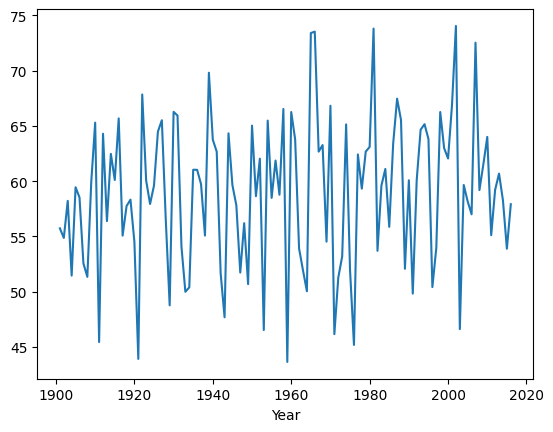

In [40]:
rainfall_df[rainfall_df['Country'] == 'Germany'].groupby('Year')['Rainfall (mm)'].mean().plot()
plt.show()

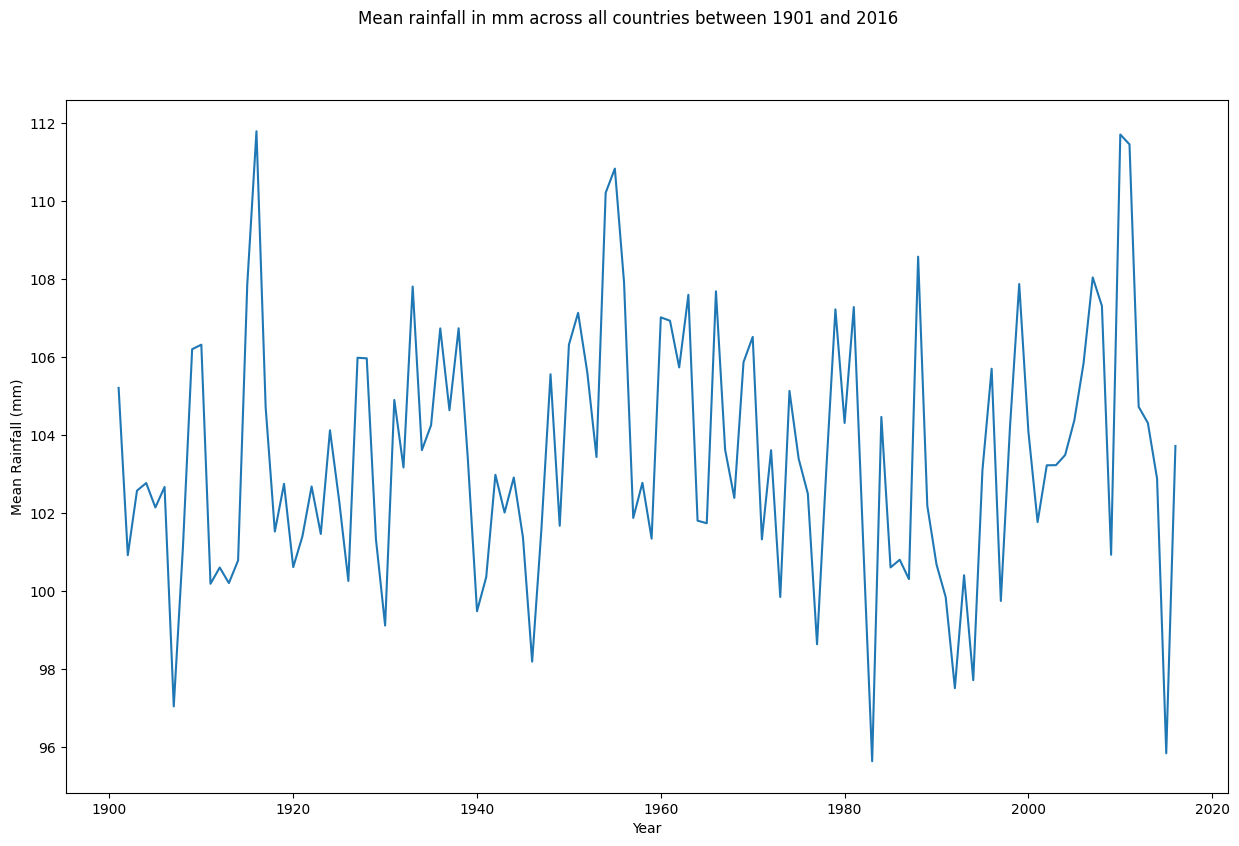

In [41]:
# prepare data
temp_data = rainfall_df.groupby('Year')['Rainfall (mm)'].mean()

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean rainfall in mm across all countries between 1901 and 2016')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Rainfall (mm)')
ax.set_xlabel('Year')

plt.show()

## Temperature data

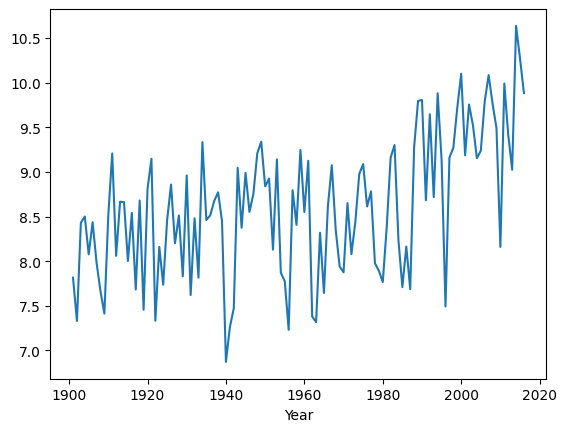

In [42]:
temperature_df[temperature_df['Country'] == 'Germany'].groupby('Year')['Temperature (Celsius)'].mean().plot()
plt.show()

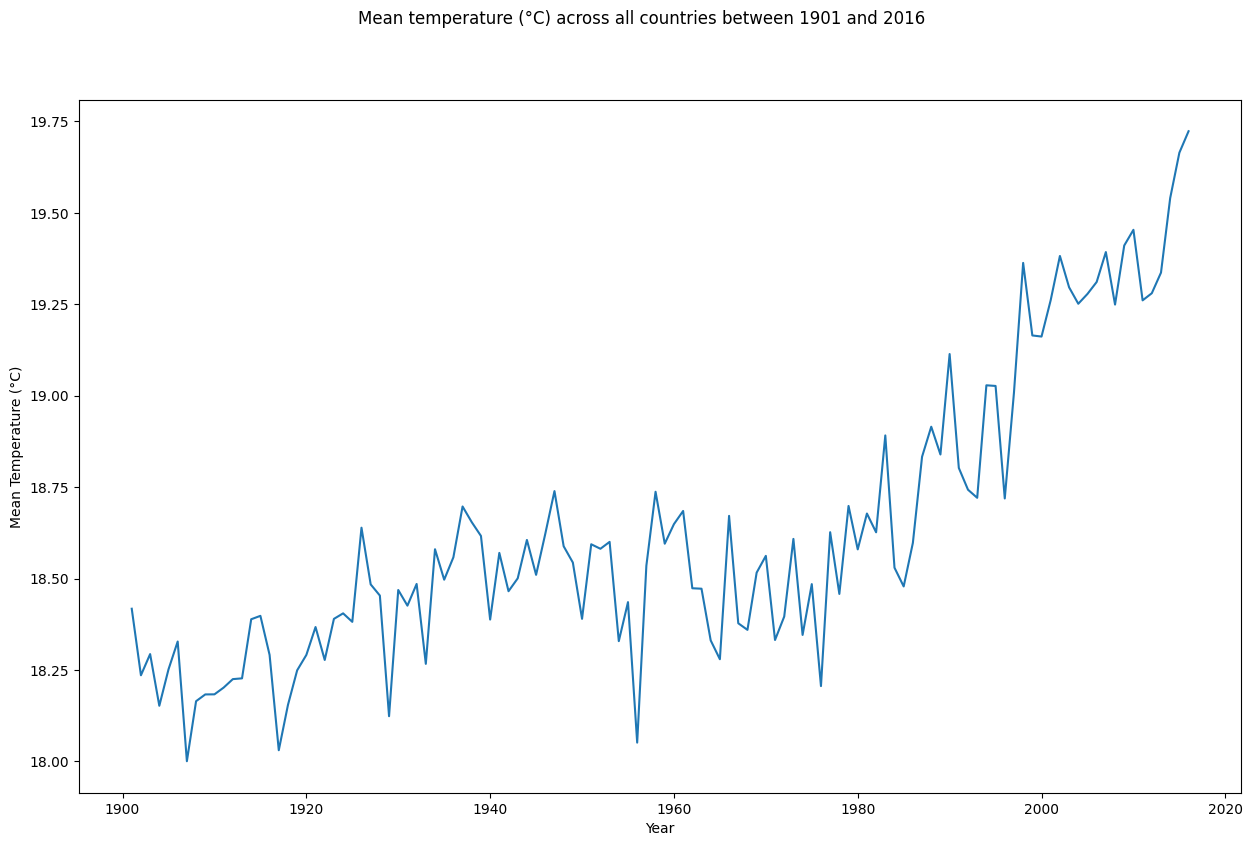

In [43]:
# prepare data
temp_data = temperature_df.groupby('Year')['Temperature (Celsius)'].mean()

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean temperature (°C) across all countries between 1901 and 2016')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Temperature (°C)')
ax.set_xlabel('Year')

plt.show()

## Yield data

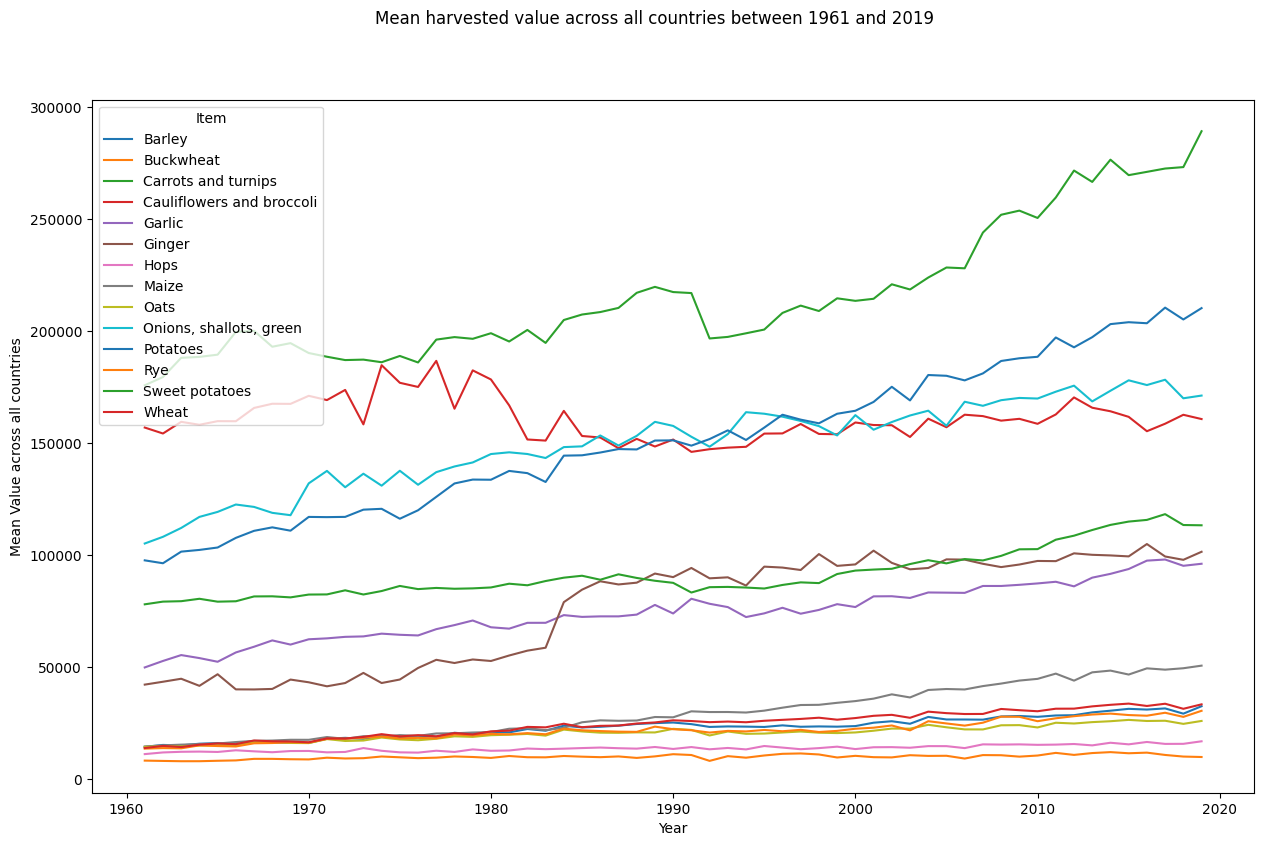

In [44]:
# prepare data
yield_mean = yield_data.groupby(['Year', 'Item'])['Yield (hg/ha)'].mean().unstack()

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean harvested value across all countries between 1961 and 2019')

yield_mean.plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

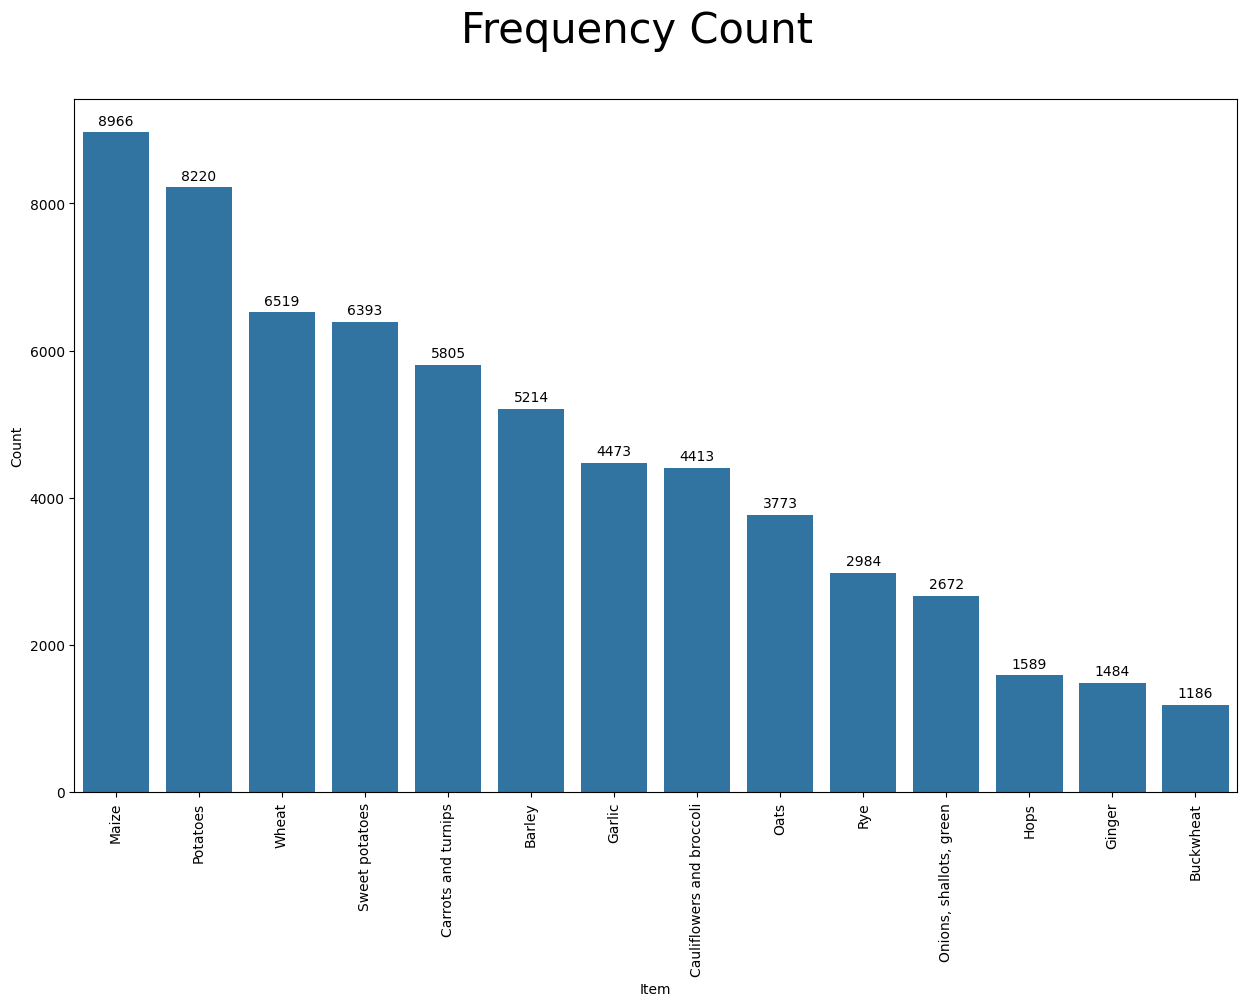

In [45]:
fig, axs = plt.subplots(1,1, figsize=(15,9))
fig.suptitle('Frequency Count', size=30)

temp_df = yield_data['Item'].value_counts().to_frame(name='Count').reset_index()
temp_df.columns = ['Item', 'Count']

g = sns.barplot(x='Item', y='Count', data=temp_df, orient='v', ax=axs)

for index, row in temp_df.iterrows():
    g.text(index, row.Count + 100, row.Count, color='black', ha="center")

axs.set_xlabel('Item')
axs.set_ylabel('Count')

plt.xticks(rotation=90)
plt.show()

## Pesticide data

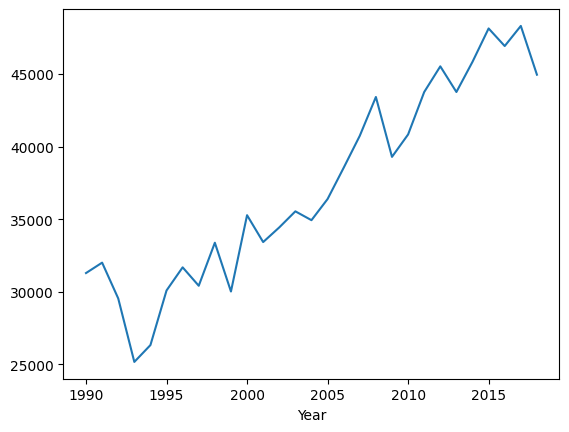

In [46]:
pesticides_df[pesticides_df['Country'] == 'Germany'].groupby('Year')['Pesticides (tonnes)'].mean().plot()
plt.show()

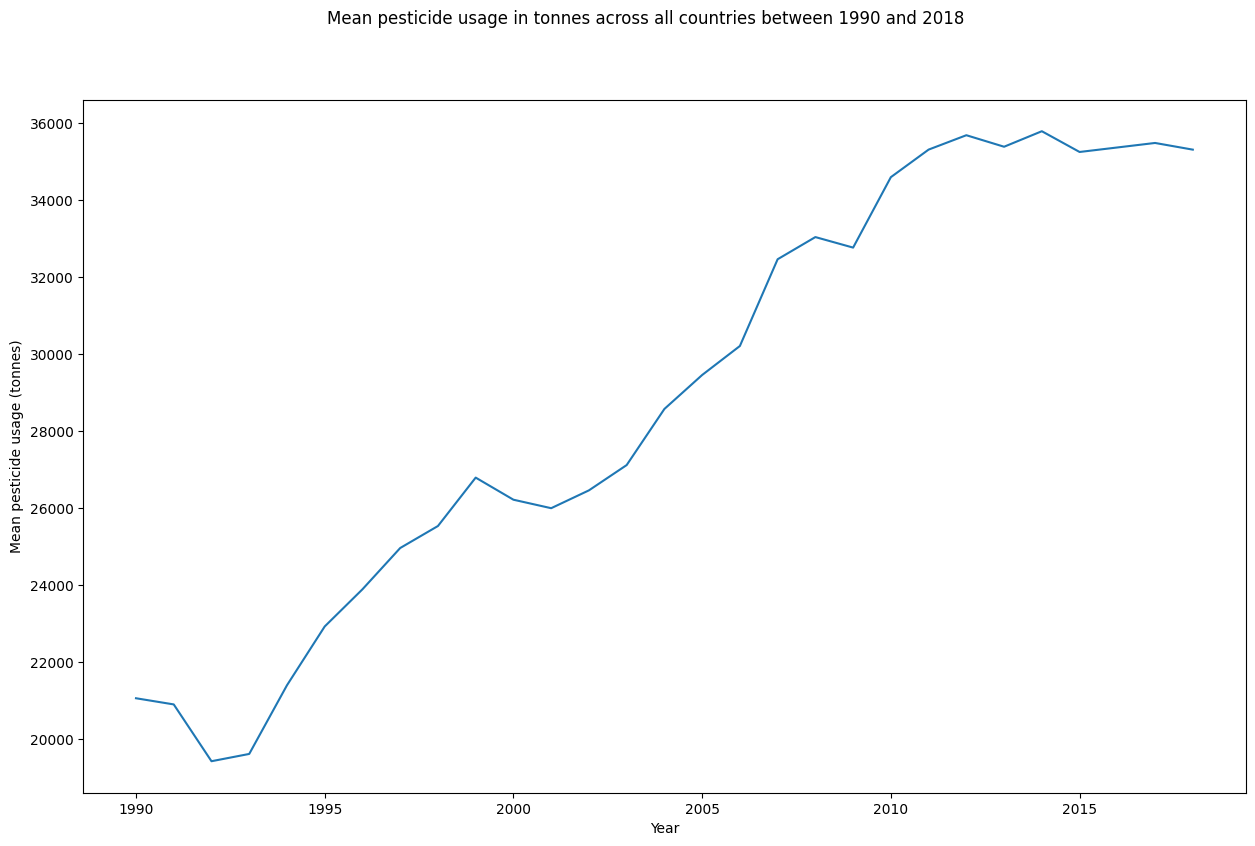

In [47]:
# prepare data
temp_data = pesticides_df.groupby('Year')['Pesticides (tonnes)'].mean()

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean pesticide usage in tonnes across all countries between 1990 and 2018')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean pesticide usage (tonnes)')
ax.set_xlabel('Year')

plt.show()


## Merged data

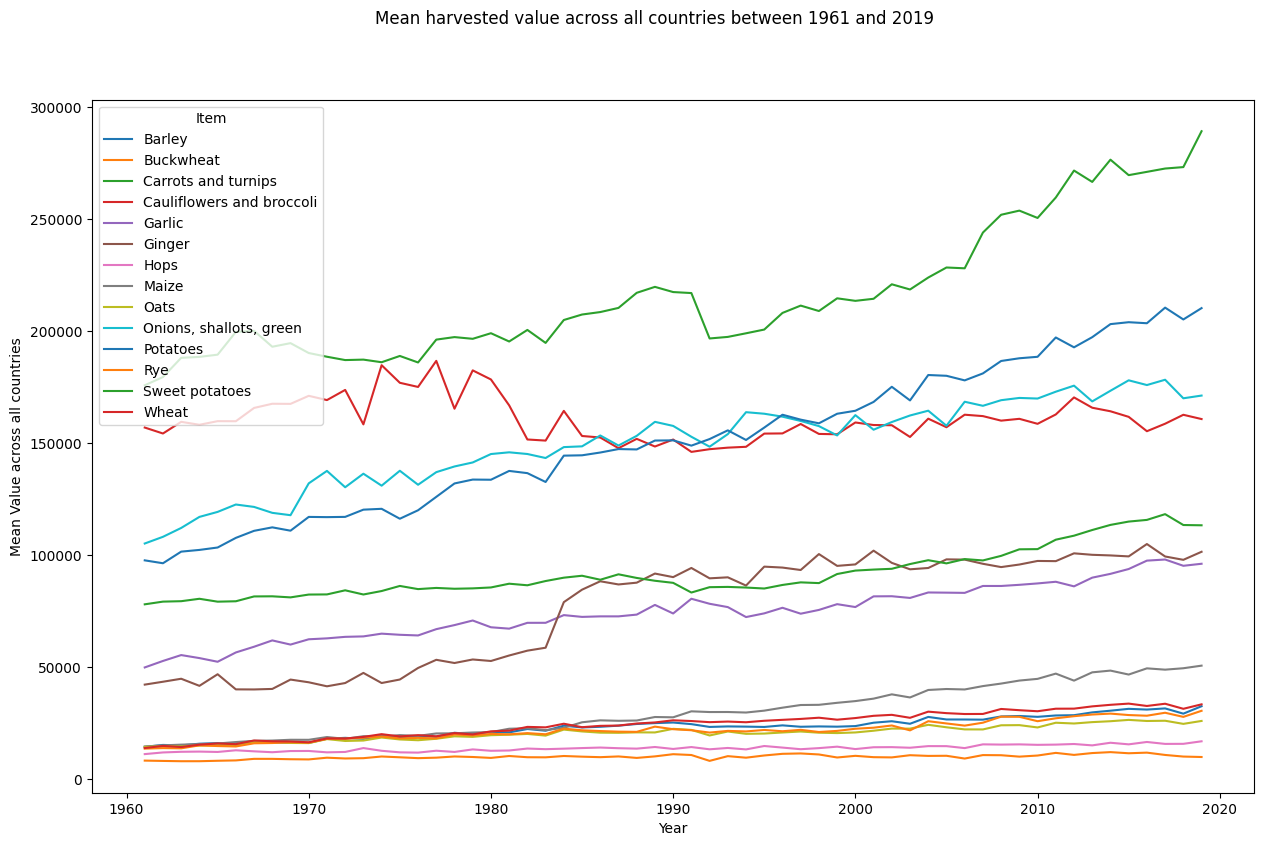

In [48]:
# prepare data
temp_data = yield_data.groupby(['Year', 'Item'])['Yield (hg/ha)'].mean().unstack()

# plot data
fig, ax = plt.subplots(figsize=(15,9))
fig.suptitle('Mean harvested value across all countries between 1961 and 2019')

temp_data.plot(ax=ax)

ax.set_ylabel('Mean Value across all countries')
ax.set_xlabel('Year')

plt.show()

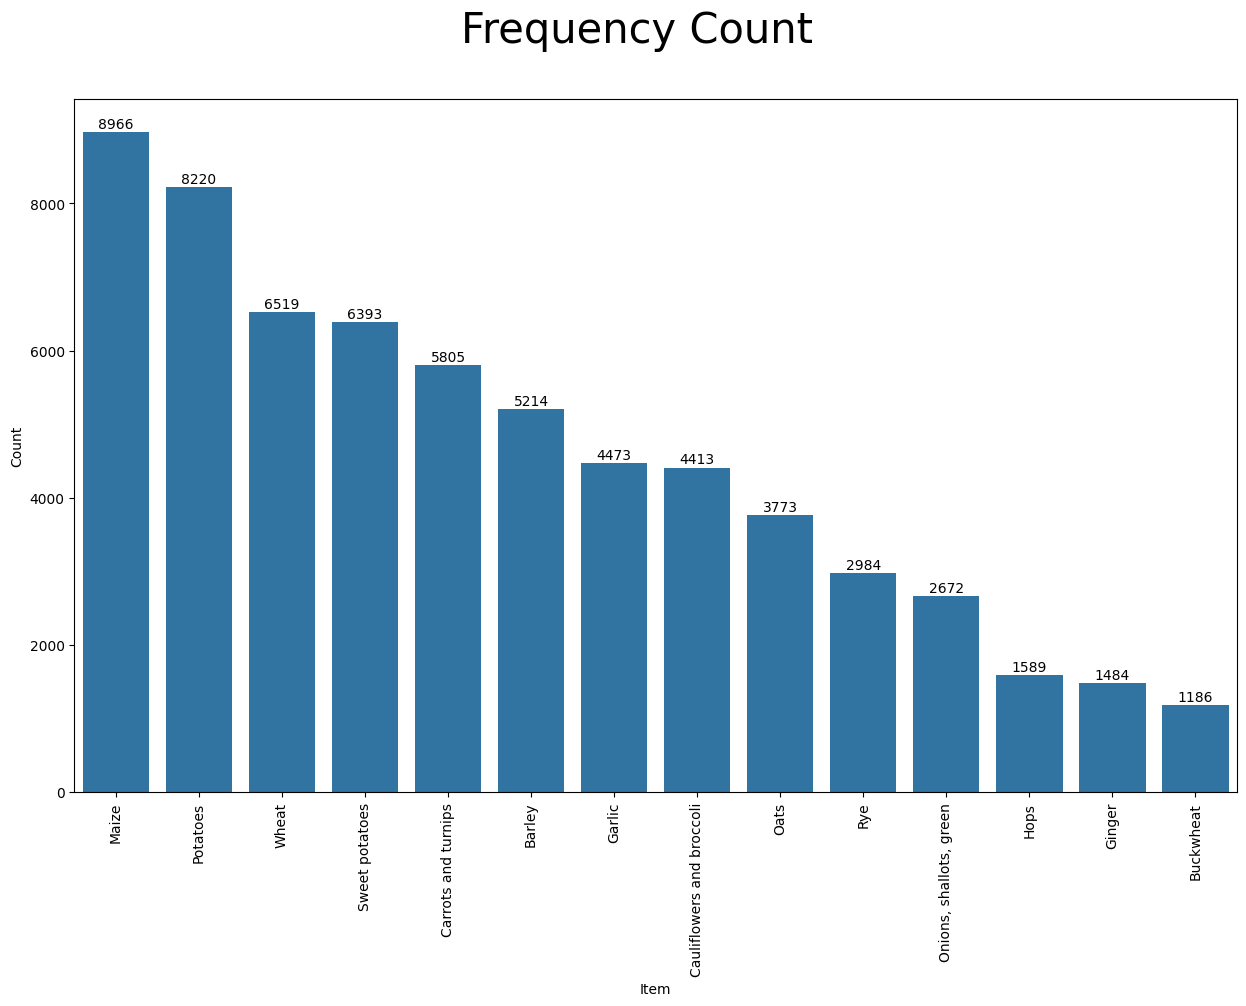

In [49]:
fig, axs = plt.subplots(1,1, figsize=(15,9))
fig.suptitle('Frequency Count', size=30)

temp_df = yield_data['Item'].value_counts().to_frame(name='Count').reset_index()
temp_df.columns = ['Item', 'Count']

g = sns.barplot(x='Item', y='Count', data=temp_df, orient='v', ax=axs)

for index, row in temp_df.iterrows():
    g.text(index, row.Count + 50, row.Count, color='black', ha="center")

axs.set_xlabel('Item')
axs.set_ylabel('Count')

plt.xticks(rotation=90)
plt.show()

<Axes: >

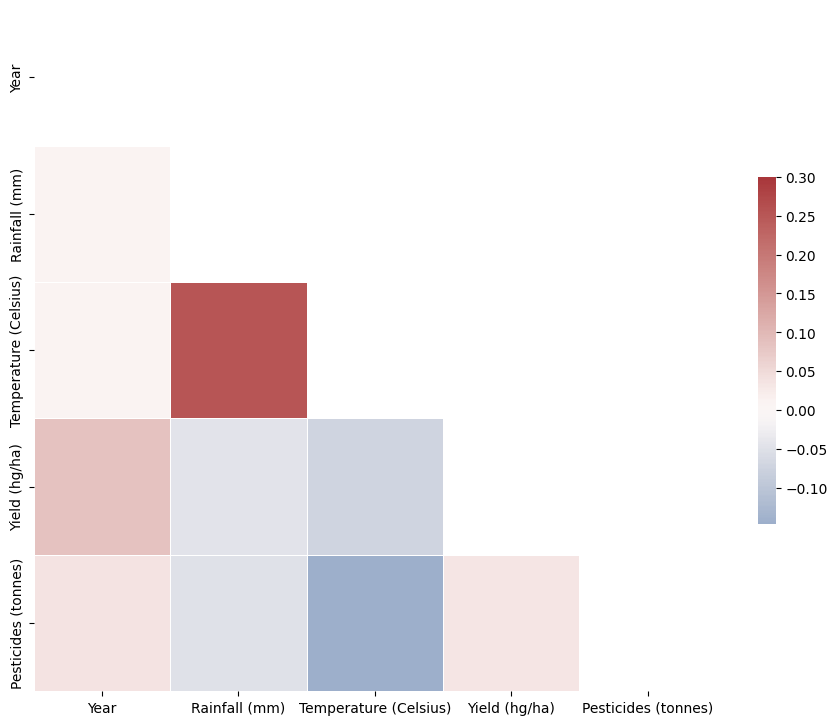

In [50]:
corr = data.select_dtypes(include=[np.number]).corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.color_palette("vlag", as_cmap=True)

# Draw the heatmap
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

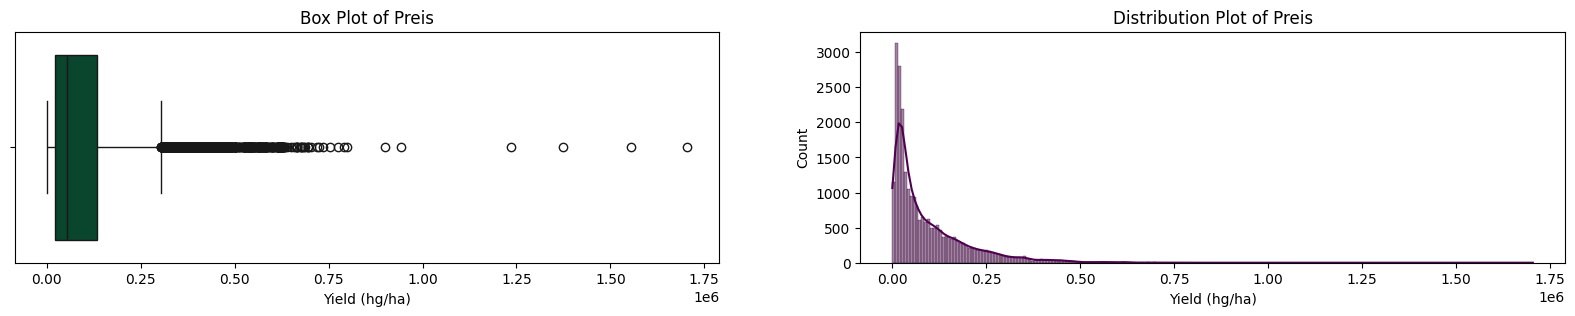

In [51]:
plt.figure(figsize=(20,3))

plt.subplot(1,2,1)
sns.boxplot(x=data['Yield (hg/ha)'],color='#005030')
plt.title(f'Box Plot of Preis')

plt.subplot(1,2,2)
sns.histplot(x=data['Yield (hg/ha)'], color='#500050', kde=True)
plt.title(f'Distribution Plot of Preis')
plt.show()

# Data Preprocessing

## One Hot Encoding

In [52]:
data.shape

(25229, 7)

In [53]:
from sklearn.preprocessing import OneHotEncoder

df_onehot = pd.get_dummies(data, columns=['Country', 'Item'], prefix=['Country', 'Item'])

X = df_onehot.drop(columns=['Yield (hg/ha)'])
y = df_onehot['Yield (hg/ha)']

In [54]:
data.shape

(25229, 7)

## Backward Elimination

In [55]:
data.shape

(25229, 7)

In [56]:
import statsmodels.api as sm

y = df_onehot['Yield (hg/ha)']
X = df_onehot.drop(columns=['Yield (hg/ha)'])

# Force numeric types
X = X.astype(float)
y = y.astype(float)

cols = list(X.columns)

while len(cols) > 0:
    X_1 = sm.add_constant(X[cols])
    model = sm.OLS(y, X_1).fit()
    p = model.pvalues.iloc[1:]
    pmax = p.max()
    feature_with_p_max = p.idxmax()

    if pmax > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

X = X[cols]
data = X.copy()
data['Yield (hg/ha)'] = y

In [57]:
data.shape

(25229, 128)

## Removing of Outliers

In [58]:
data.shape

(25229, 128)

In [59]:
from scipy import stats

y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

z_scores = stats.zscore(X)
abs_z_scores = np.abs(z_scores)

filtered_entries = (abs_z_scores < 11).all(axis=1)

X = X[filtered_entries]
y = y[filtered_entries]

data = X.copy()
data['Yield (hg/ha)'] = y

In [60]:
data.shape

(18345, 128)

## Feature Scaling

In [61]:
data.shape

(18345, 128)

In [62]:
from sklearn.preprocessing import MinMaxScaler

y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

data_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
data_scaled['Yield (hg/ha)'] = y

data = data_scaled

In [63]:
data.shape

(18345, 128)

# Modeling

In [64]:
y = data['Yield (hg/ha)']
X = data.drop('Yield (hg/ha)', axis=1)

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [67]:
from scipy.stats import linregress

def plot_regression_results(ax, y_test, y_pred, title, estimated_time, scores):

    # linear least-squares
    slope, intercept, rvalue, pvalue, stderr = linregress(y_test, y_pred)
    ax.plot([y_test.min(), y_test.max()],
            [intercept + y_test.min()*slope,
             intercept + y_test.max()*slope],
            '--r')

    ax.scatter(y_test, y_pred, alpha=0.7)

    # score box
    extra = plt.Rectangle((0, 0), 0, 0, fc="w", fill=False,
                          edgecolor='none', linewidth=0)
    ax.legend([extra], [scores], loc='upper left')

    ax.set_xlabel('Actual values in tonnes')
    ax.set_ylabel('Predicted values in tonnes')
    ax.set_title('{}\nTrained in {:.2f} Milliseconds'.format(title, estimated_time*1000))


In [68]:
# esmimators list since it gets lost each time python environment resets 

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

lin = LinearRegression()
dtr = DecisionTreeRegressor()
sgd = SGDRegressor(loss='squared_error')
gbr = GradientBoostingRegressor()
knn = KNeighborsRegressor(n_neighbors=5)
rfr = RandomForestRegressor()

estimators = [
    ('Linear Regression', lin),
    ('Decision Tree Regression', dtr),
    ('Stochastic Gradient Descent Regression', sgd),
    ('Gradient Boosting Regression', gbr),
    ('K-nearest Neighbour 5', knn),
    ('Random Forest Regression', rfr)
]


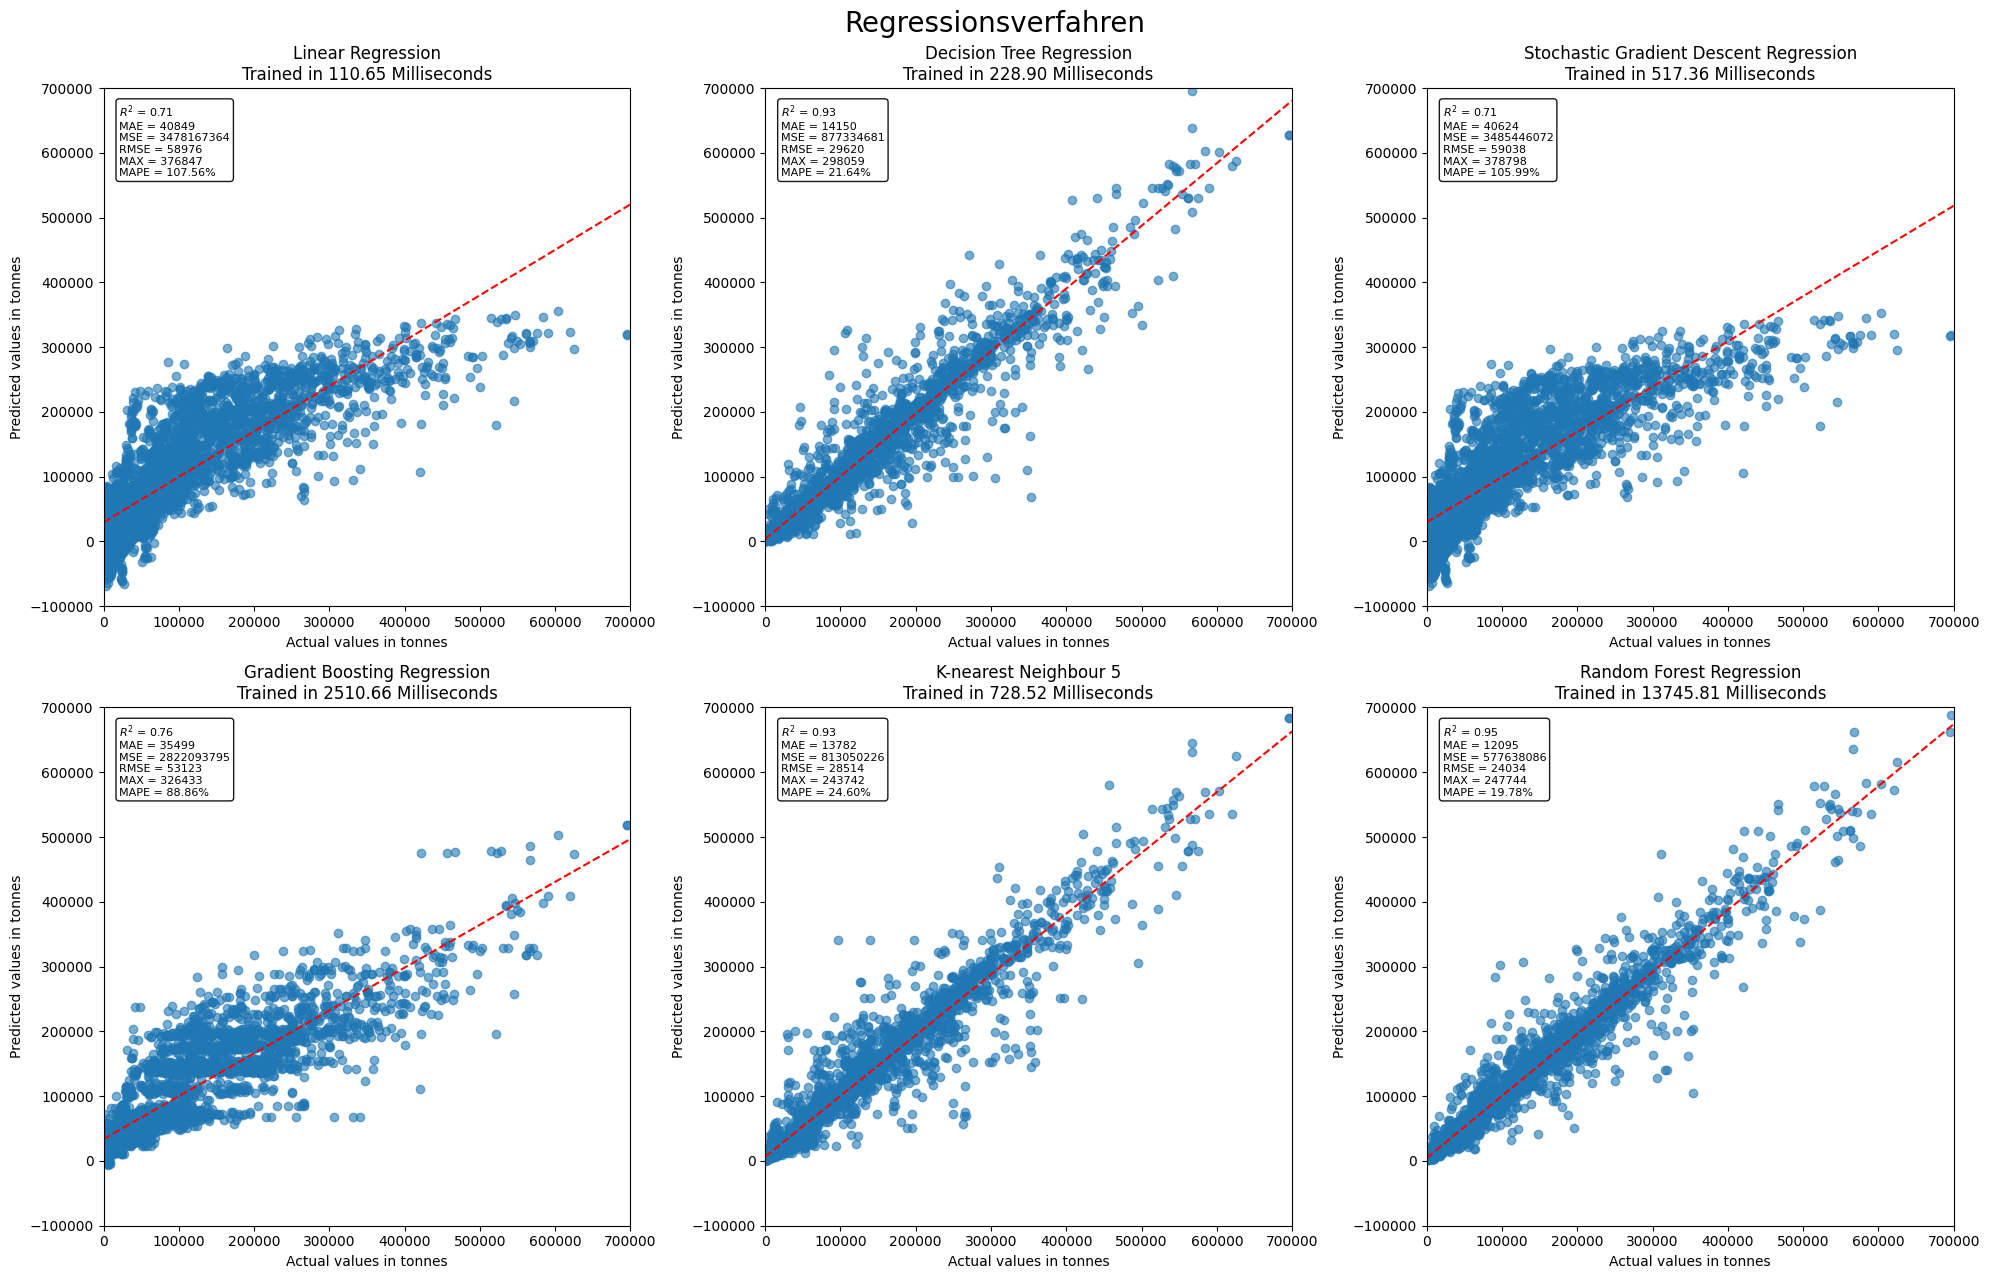

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import time
from scipy.stats import linregress
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, max_error

plt.style.use('default')

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def plot_regression_results(ax, y_test, y_pred, name, estimated_time, scores):

    slope, intercept, *_ = linregress(y_test, y_pred)

    ax.plot([0, 700000],
            [intercept, intercept + 700000*slope],
            '--r')

    ax.scatter(y_test, y_pred, alpha=0.6)

    ax.set_xlim(0, 700000)
    ax.set_ylim(-100000, 700000)

    props = dict(boxstyle='round', facecolor='white', alpha=0.9)

    ax.text(0.03, 0.97, scores,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=props)

    ax.set_xlabel('Actual values in tonnes')
    ax.set_ylabel('Predicted values in tonnes')
    ax.set_title(f'{name}\nTrained in {estimated_time*1000:.2f} Milliseconds')


fig, axs = plt.subplots(2, 3, figsize=(20, 13))
axs = axs.ravel()

for ax, (name, est) in zip(axs, estimators):

    start = time.time()
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    elapsed = time.time() - start

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # 🔥 shorten numbers like old notebook
    scores = (
        f"$R^2$ = {r2_score(y_test, y_pred):.2f}\n"
        f"MAE = {mean_absolute_error(y_test, y_pred):.0f}\n"
        f"MSE = {mean_squared_error(y_test, y_pred):.0f}\n"
        f"RMSE = {rmse:.0f}\n"
        f"MAX = {max_error(y_test, y_pred):.0f}\n"
        f"MAPE = {mean_absolute_percentage_error(y_test, y_pred):.2f}%"
    )

    plot_regression_results(ax, y_test, y_pred, name, elapsed, scores)

plt.suptitle('Regressionsverfahren', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


/var/folders/3j/8s97_xgd4735v6_5l0z3tps40000gn/T/ipykernel_52345/3462224450.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot(r2_values, labels=names)
/var/folders/3j/8s97_xgd4735v6_5l0z3tps40000gn/T/ipykernel_52345/3462224450.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot(max_error_values, labels=names)
/var/folders/3j/8s97_xgd4735v6_5l0z3tps40000gn/T/ipykernel_52345/3462224450.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot(mae_values, labels=names)
/var/folders/3j/8s97_xgd4735v6_5l0z3tps40000gn/T/ipykernel_52345/3462224450.py:47: MatplotlibDeprecationWarnin

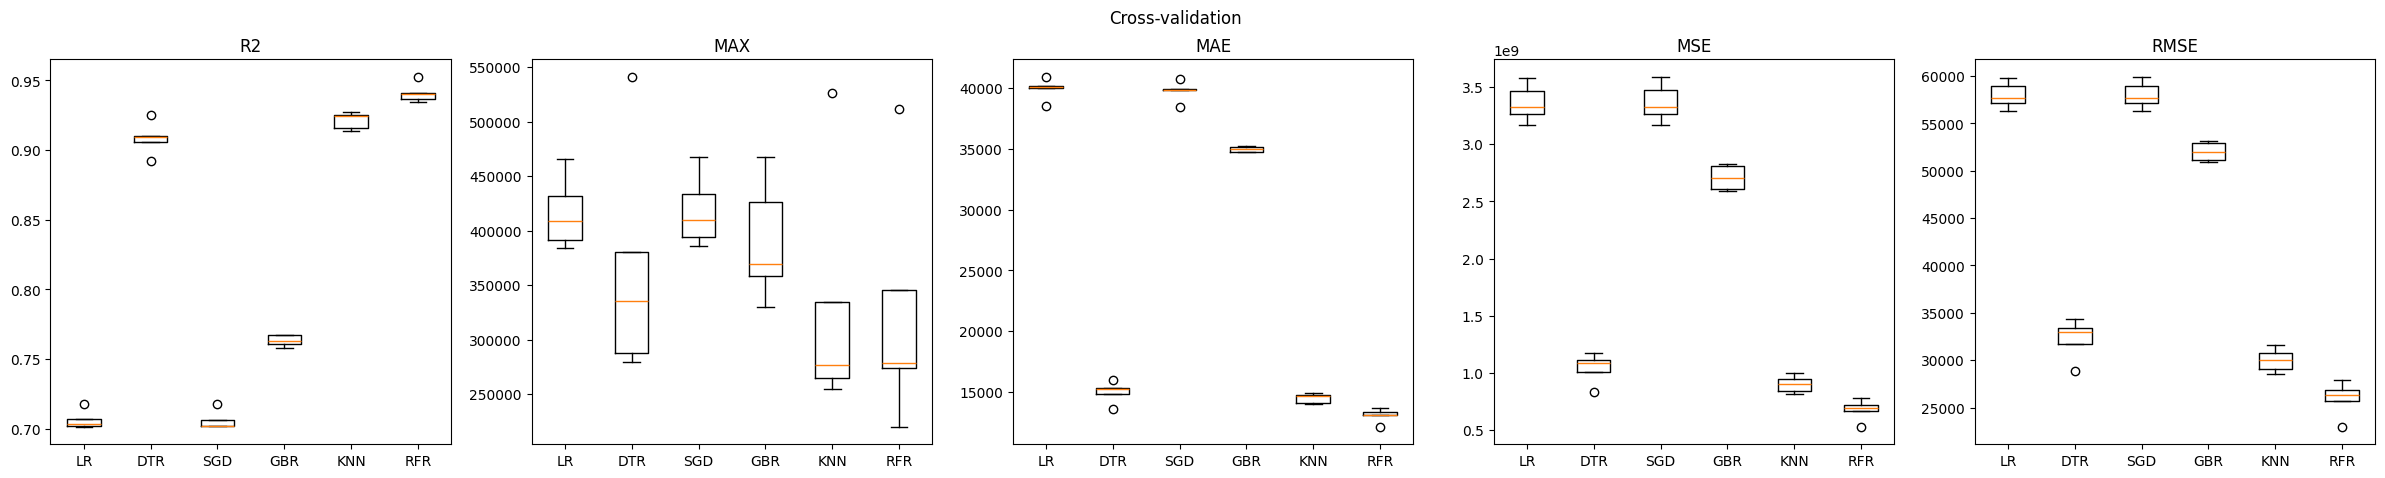

In [70]:
# Required import
from sklearn.model_selection import cross_validate

r2_values = []
max_error_values = []
mae_values = []
mse_values = []
rmse_values = []

for name, est in estimators:

    score = cross_validate(
        est,
        X_train,
        y_train,
        cv=5,
        scoring=[
            'r2',
            'max_error',
            'neg_mean_absolute_error',
            'neg_mean_squared_error'
        ],
        n_jobs=-1
    )

    # Store values (convert negatives back)
    r2_values.append(score['test_r2'])
    max_error_values.append(-score['test_max_error'])
    mae_values.append(-score['test_neg_mean_absolute_error'])
    mse_values.append(-score['test_neg_mean_squared_error'])
    rmse_values.append(np.sqrt(-score['test_neg_mean_squared_error']))

# Plot results
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(30, 5))

names = ['LR', 'DTR', 'SGD', 'GBR', 'KNN', 'RFR']

axs[0].boxplot(r2_values, labels=names)
axs[0].set_title('R2')

axs[1].boxplot(max_error_values, labels=names)
axs[1].set_title('MAX')

axs[2].boxplot(mae_values, labels=names)
axs[2].set_title('MAE')

axs[3].boxplot(mse_values, labels=names)
axs[3].set_title('MSE')

axs[4].boxplot(rmse_values, labels=names)
axs[4].set_title('RMSE')

plt.suptitle('Cross-validation')
plt.show()


In [71]:
r2_values = []
max_error_values = []
neg_mean_absolute_error_values = []
neg_mean_squared_error_values = []
neg_root_mean_squared_error_values = []


In [72]:
from sklearn.model_selection import cross_validate
import numpy as np

for name, est in estimators:
    score = cross_validate(
        est,
        X_train,
        y_train,
        cv=5,
        scoring={
            'r2': 'r2',
            'max_error': 'max_error',
            'mae': 'neg_mean_absolute_error',
            'mse': 'neg_mean_squared_error',
            'rmse': 'neg_root_mean_squared_error'
        },
        n_jobs=-1
    )

    r2_values.append(score['test_r2'])
    max_error_values.append(-score['test_max_error'])
    neg_mean_absolute_error_values.append(-score['test_mae'])
    neg_mean_squared_error_values.append(-score['test_mse'])
    neg_root_mean_squared_error_values.append(-score['test_rmse'])


In [73]:
regression = 5

print(u'R²: {:.3f} \u00B1 {:.3f}'.format(np.mean(r2_values[regression]), np.std(r2_values[regression])))
print(u'MAX: {:,.0f} \u00B1 {:,.0f}'.format(np.mean(max_error_values[regression]), np.std(max_error_values[regression])))
print(u'MAE: {:,.0f} \u00B1 {:,.0f}'.format(np.mean(neg_mean_absolute_error_values[regression]), np.std(neg_mean_absolute_error_values[regression])))
print(u'MSE: {:,.0f} \u00B1 {:,.0f}'.format(np.mean(neg_mean_squared_error_values[regression]), np.std(neg_mean_squared_error_values[regression])))
print(u'RMSE: {:,.0f} \u00B1 {:,.0f}'.format(np.mean(neg_root_mean_squared_error_values[regression]), np.std(neg_root_mean_squared_error_values[regression])))


R²: 0.942 ± 0.006
MAX: 318,753 ± 109,725
MAE: 12,982 ± 493
MSE: 669,710,274 ± 80,070,815
RMSE: 25,830 ± 1,594


In [74]:
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
import pydot

# smaller forest for visualization
rfr_small = RandomForestRegressor(max_depth=4, n_estimators=10)
rfr_small.fit(X_train, y_train)

tree = rfr_small.estimators_[0]

export_graphviz(
    tree,
    out_file='tree_small.dot',
    feature_names=X_train.columns,
    rounded=True,
    precision=1,
    max_depth=4
)

(graph,) = pydot.graph_from_dot_file('tree_small.dot')

# reduce resolution
graph.set_dpi(100)

graph.write_png('tree_small.png')

print("tree_small.png created")

tree_small.png created
